# Chapter 2: Supervised Learning and Energy Landscapes
## Practical: Implementing Linear Regression and SGD

### Setup: Generate Synthetic Data

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# Generate synthetic data: y = 2*x1 - 3*x2 + 0.5 + noise
np.random.seed(42)
N = 1000
d = 2
X = np.random.randn(N, d)
true_w = np.array([2.0, -3.0])
true_b = 0.5
y = X @ true_w + true_b + 0.1 * np.random.randn(N)

# Add a column of ones for the bias
X_aug = np.hstack([np.ones((N, 1)), X])
theta_true = np.concatenate([[true_b], true_w])

print(f"True parameters: bias={true_b:.2f}, w={true_w}")
print(f"Data shape: X={X.shape}, y={y.shape}")

True parameters: bias=0.50, w=[ 2. -3.]
Data shape: X=(1000, 2), y=(1000,)


### Closed-Form Solution (Normal Equations)

In [2]:
theta_cf = np.linalg.lstsq(X_aug, y, rcond=None)[0]
print(f"Closed-form solution: bias={theta_cf[0]:.4f}, w={theta_cf[1:]}")

Closed-form solution: bias=0.5004, w=[ 2.0027767  -2.99828491]


### Gradient Descent from Scratch

In [3]:
def mse_gradient(X_aug, y, theta):
    """Compute gradient of MSE loss."""
    N = len(y)
    return (1/N) * X_aug.T @ (X_aug @ theta - y)

def gradient_descent(X_aug, y, theta_init, lr=0.01, n_iter=500, reg=0.0):
    """Perform gradient descent with optional L2 regularisation."""
    theta = theta_init.copy()
    history = [theta.copy()]
    losses = []
    
    for i in range(n_iter):
        grad = mse_gradient(X_aug, y, theta) + reg * theta
        theta -= lr * grad
        history.append(theta.copy())
        losses.append(np.mean((X_aug @ theta - y)**2) / 2)
    
    return theta, np.array(history), np.array(losses)

# Initialise and run
theta_init = np.random.randn(3)
theta_gd, history, losses = gradient_descent(X_aug, y, theta_init, 
                                             lr=0.05, n_iter=200, reg=0.01)

print(f"GD solution: bias={theta_gd[0]:.4f}, w={theta_gd[1:]}")

GD solution: bias=0.4944, w=[ 1.98126493 -2.96900297]


### Compare with scikit-learn

In [4]:
sk_lr = LinearRegression(fit_intercept=False)
sk_lr.fit(X_aug, y)
print(f"scikit-learn: bias={sk_lr.coef_[0]:.4f}, w={sk_lr.coef_[1:]}")

scikit-learn: bias=0.5004, w=[ 2.0027767  -2.99828491]


### Plot Convergence

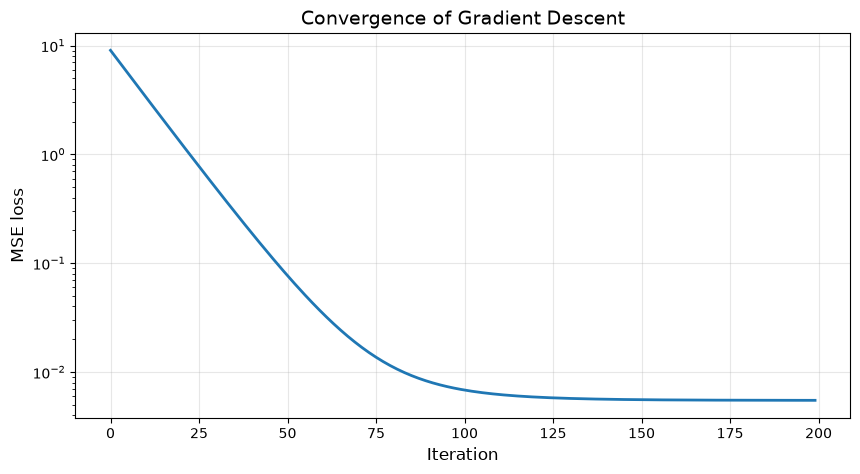

In [5]:
plt.figure(figsize=(10, 5))
plt.semilogy(losses, linewidth=2)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('MSE loss', fontsize=12)
plt.title('Convergence of Gradient Descent', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

### Stochastic Gradient Descent

In [6]:
def sgd(X_aug, y, theta_init, lr=0.01, epochs=100, batch_size=32, reg=0.0):
    """Stochastic gradient descent with minibatches."""
    theta = theta_init.copy()
    N = len(y)
    loss_history = []
    
    for epoch in range(epochs):
        indices = np.random.permutation(N)
        epoch_loss = 0
        for start in range(0, N, batch_size):
            batch_idx = indices[start:start+batch_size]
            X_b = X_aug[batch_idx]
            y_b = y[batch_idx]
            grad = (1/len(batch_idx)) * X_b.T @ (X_b @ theta - y_b) + reg * theta
            theta -= lr * grad
            epoch_loss += np.mean((X_b @ theta - y_b)**2) / 2
        
        loss_history.append(epoch_loss / (N // batch_size))
    
    return theta, np.array(loss_history)

theta_sgd, sgd_losses = sgd(X_aug, y, theta_init, lr=0.01, epochs=100)
print(f"SGD solution: bias={theta_sgd[0]:.4f}, w={theta_sgd[1:]}")

SGD solution: bias=0.5007, w=[ 2.00246296 -2.99859218]


### Compare GD vs SGD

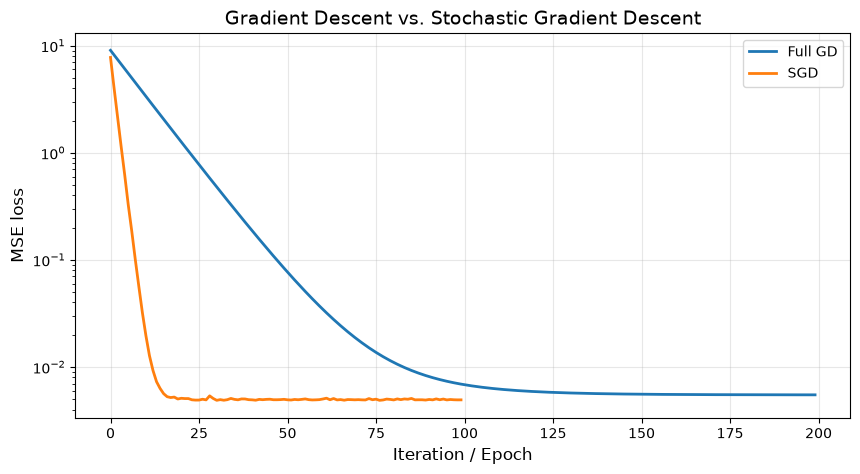

In [7]:
plt.figure(figsize=(10, 5))
plt.semilogy(losses, label='Full GD', linewidth=2)
plt.semilogy(sgd_losses, label='SGD', linewidth=2)
plt.xlabel('Iteration / Epoch', fontsize=12)
plt.ylabel('MSE loss', fontsize=12)
plt.title('Gradient Descent vs. Stochastic Gradient Descent', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Observations

- The closed-form solution recovers the true parameters.
- Gradient descent approaches the same minimum with convergence determined by the condition number.
- SGD fluctuates around the optimum (Langevin dynamics) but is computationally faster.
- The variance of SGD fluctuations is proportional to learning rate and inversely proportional to batch size.